# Nuclear moments

In this example, we show the plot of the Kubo-Toyabe depolarization function at muon site which reflects the field distribution at the muon site due to the nuclear moments, with the second moment (width) of the field distribution computed in the limit of strong quadrupolar interactions, taking into account isotope averages and the lattice distortions induced by the muon.

This results is highlighted in the aiida-muon paper [here](https://iris.unimore.it/retrieve/handle/11380/1375349/785889/d4dd00314d.pdf).

In [1]:
import numpy as np
from copy import deepcopy

# for plotting if needed
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants

from muonscripts.io_tools.read import read_cif
from muonscripts.io_tools.read import read_from_file

from muonscripts.io_tools.load_relax import load_relax
from muonscripts.io_tools.load_relax import save_relax_results
from muonscripts.io_tools.load_relax import load_relax_results
from muonscripts.io_tools.find_qe_files import select_groups
from muonscripts.io_tools.find_qe_files import get_relax_after_run
from muonscripts.io_tools.find_qe_files import print_relax_summary
from muonscripts.io_tools.find_qe_files import load_relax_from_folder

from muonscripts.undi_tools.second_moments_avg import second_moments_fn
from muonscripts.undi_tools.second_moments import zero_field_distribution_powder

from muonscripts.undi_tools.atoms_scaling import scale_neighbors, partition_into_shells
from muonscripts.undi_tools.atoms_scaling import only_muon_cluster, compute_zeta_cluster

from muonscripts.undi_tools.atoms import build_undi_neighbors, build_undi_neighbors_from_file
from muonscripts.undi_tools.atoms import complete_undi_neighbors, neighbors_hilbert_dimension

from muonscripts.pcefg.point_charge import compute_efg
from muonscripts.pcefg.point_charge import sphere_radius_convergence
from muonscripts.pcefg.point_charge import build_point_charge_efg_neighbors

# from muonscripts.pcefg.utils import nu_Q, quadrupole_frequencies, get_omegaQ_mu
# from muonscripts.pcefg.point_charge import compute_efg, point_charge_EFG, diagonalize_EFG, atom_dict_EFG

from muonscripts.muon_tools.displacements import radial_to_dict
from muonscripts.muon_tools.displacements import max_displacement
from muonscripts.muon_tools.displacements import select_radial_displacement

from muonscripts.muon_tools.aiida_muon.sites_supercells import gensup
from muonscripts.muon_tools.aiida_muon.sites_supercells import niche_add_impurities
from muonscripts.muon_tools.aiida_muon.sites_supercells import compute_suggest_supercell_size

from muonscripts.muon_tools.aiida_muon.distortions import get_distortions
from muonscripts.muon_tools.aiida_muon.clustering import get_clustering_after_run_from_data

from muonscripts.muon_tools.aiida_muon.clustering_report import print_clustering_summary

In [3]:
def load_raw_data_only(filename, x_min=0):
    """Reads the first 2-3 columns (xData, Data, [errData]) of a muSR
    data file, ignoring any other (e.g. theory) columns."""
    import pandas as pd
    
    df = pd.read_csv(filename, skipinitialspace=True)
    df = df.replace(r"^\s*$", np.nan, regex=True)
    cols = list(df.columns[:3])
    d = df[cols].dropna()
    xData = d[cols[0]].to_numpy(dtype=float)
    yData = d[cols[1]].to_numpy(dtype=float)
    errData = d[cols[2]].to_numpy(dtype=float) if len(cols) > 2 else None
    if x_min is not None:
        keep = xData >= x_min
        xData, yData = xData[keep], yData[keep]
        if errData is not None:
            errData = errData[keep]
    return xData, yData, errData


def _ordered_legend(ax, order_list, **legend_kwargs):
    handles, labels = ax.get_legend_handles_labels()

    def priority(label):
        for i, key in enumerate(order_list):
            if key in label:
                return i
        return len(order_list)

    entries = sorted(
        zip(handles, labels),
        key=lambda e: priority(e[1])
    )

    handles, labels = zip(*entries)

    return ax.legend(handles, labels, **legend_kwargs)

In [4]:
def powder_celio_signal(
    neighbors, 
    tlist, 
    k=2, 
    nrep=1,
    single_precision=False, 
    algorithm='light',
    log_level='',
    undi_path='/home/misah/projects/myproject/undi'
):
    """Powder-averaged P_z^mu(t) via undi.py's celio_on_steroids(), using
    the SAME exact 3-orthogonal-axis trick as the exact-diagonalization
    path elsewhere in this thread (mathematically exact for zero-field
    muon depolarization, independent of which method solves the
    dynamics underneath -- see wilkinson_prl_example.py's derivation).

    REQUIRES the compiled backend (fast_quantum_light or similar) that
    ships with the full `undi` package -- NOT importable from just
    undi.py + isotopes.py as used elsewhere in this thread. If you see
    ImportError here, you need `pip install undi` (or build the C++
    extensions from the undi source repo) rather than just using the
    loose undi.py file.

    nrep : int
        Number of independent Celio stochastic repeats to average over
        (in ADDITION to averaging over the 3 powder directions) -- more
        repeats reduce the Monte Carlo noise in the result. The paper's
        own SM mentions similar repeat-averaging for their Celio-based
        A15 simulations.
    """
    # Importing stuff...
    try:
        from undi import MuonNuclearInteraction
    except (ImportError, ModuleNotFoundError):
        import sys
        sys.path.append(undi_path)
        from undi import MuonNuclearInteraction

    signal = np.zeros(len(tlist))
    for direction in ([1, 0, 0], [0, 1, 0], [0, 0, 1]): # simple powder average
        NS = MuonNuclearInteraction(neighbors, log_level=log_level)
        NS.translate_rotate_sample_vec(direction)   # rotates geometry directly
        for _ in range(nrep):
            signal += NS.celio_on_steroids(
                tlist, k=k, single_precision=single_precision, progress=False, algorithm=algorithm
            )
    return signal / (3 * nrep)

In [5]:
def kubo_toyabe(tlist, Gmu_S2):
    """Calculates the Kubo-Toyabe polarization for the nuclear arrangement
        provided in input.

    Parameters
    ----------
    tlist : numpy.array
        List of times at which the muon polarization is observed.
    Gmu_S2 : float
        The product of gamma_mu and sigma^2.

    Returns
    -------
    numpy.array
        Kubo-Toyabe function, for a powder in zero field.
    """
    return 0.333333333333 + 0.6666666666 * \
            (1- Gmu_S2  *  np.power(tlist,2)) * \
            np.exp( - 0.5 * Gmu_S2 * np.power(tlist,2))

In [6]:
import os
dpath='./'

In [7]:
file = 'RVS_relax_siteA.in'
file = os.path.join(dpath, file)
inp_ase  = read_from_file(file, format="espresso-in")
inp_ase2 = inp_ase.copy() 

In [ ]:
file = 'RVS_relax_siteA.out'
file = os.path.join(dpath, file)
rlx_ase  = read_from_file(file, format="espresso-out", index=-1)
rlx_ase2 = rlx_ase.copy()

In [9]:
# get and remove muon position
rlx_ase2 =  rlx_ase.copy()
if 1 not in rlx_ase2.numbers:
    raise ValueError("No Hydrogen (atomic number 1) found in rlx_ase2.")
mu_idx = np.where(rlx_ase2.numbers == 1)[0][-1]
mupos_rlx = rlx_ase2.get_scaled_positions()[mu_idx]
del rlx_ase2[mu_idx]

mupos_rlx

array([0.        , 0.        , 0.11938324])

In [10]:
inf_cutoff=10
cutoffs = {'Rb': 3.0, 'V': 4.00, 'Sb': 2.0}
cutoffs = {'Rb': 3.0, 'V': 3.53, 'Sb': 2.0}
print("== Building neighbor cluster ==")
neighbors = build_undi_neighbors(
    rlx_ase2,
    mupos_rlx,
    cutoffs=cutoffs,
    inf_cutoff=inf_cutoff,
    efg_tensors=None,
    efg_factor=1.0,
    gamma_overrides=None,
    isotope_overrides=None,
    quadrupole_moments_overrides=None,
    verbose_neighbors=True,
    # format='elk'
    # **read_kwargs,
)

# complete missing nuclear properties
neighbors = complete_undi_neighbors(neighbors, log_level="")

neighbors

neighbors_hilbert_dimension(neighbors)

== Building neighbor cluster ==
Adding atom #218 V    with position (Å): [  2.7646,   0.0000,  -2.1869] and distance: 3.5250 Å
Adding atom #15  Rb   with position (Å): [  0.0000,   0.0000,   2.6291] and distance: 2.6291 Å
Adding atom #61  Sb   with position (Å): [  0.0000,   0.0000,  -1.7701] and distance: 1.7701 Å
Adding atom #267 V    with position (Å): [ -2.7646,   0.0000,  -2.1869] and distance: 3.5250 Å


4608

In [11]:
# Time values, in seconds
tlist = np.linspace(0, 16e-6, 1000)
# tlist = np.linspace(0.0, 15e-6, 101)
tlist_us = tlist*1e6

In [12]:
# signals = powder_celio_signal(
#     neighbors, tlist=tlist, k=4, nrep=2, single_precision=True, algorithm='fast')

In [13]:
cutoffs_deep = {'Rb': 3.00, 'V': 3.53, 'Sb': 2.00}
sm_contribs = second_moments_fn(
    atoms=rlx_ase.copy(), 
    muon_position=None, 
    cutoff=cutoffs_deep
)
Gmu_S2 = sum(sm_contribs.values())

print('Contributions to the total second moment (sigma^2) from each nuclear species:')
width = max((len(s) for s in sm_contribs), default=5)
width = max(width, len('Total'))

# Loop over species and print absolute + percentage contributions
for symbol, val in sm_contribs.items():
    pct = (val / Gmu_S2) * 100 if Gmu_S2 > 0 else 0.0
    print(f"  {symbol:>{width}s}: {val:20.6f} (rad^2/s^2) | {pct:7.3f}%")
print(f"  {'Total':>{width}s}: {Gmu_S2:20.6f} (rad^2/s^2) | 100.000%")

Contributions to the total second moment (sigma^2) from each nuclear species:
      V:    4375791972.439541 (rad^2/s^2) |   7.671%
     Rb:    2002136870.928100 (rad^2/s^2) |   3.510%
     Sb:   50667736241.770142 (rad^2/s^2) |  88.820%
  Total:   57045665085.137787 (rad^2/s^2) | 100.000%


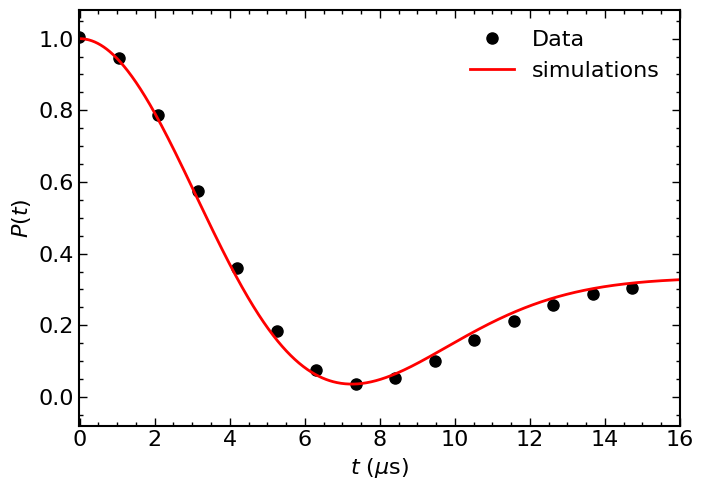

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))


file = 'RVS_ZFmuSR_120K_data.dat'
file = os.path.join(dpath, file)
data = np.loadtxt(
    file,
    delimiter=",",
    # skiprows=1
)
t = data[:, 0]
y = data[:, 1]

ax.errorbar(t, y, yerr=None, fmt='o', color='k', alpha=1.0, ms=8, label='Data')
ax.errorbar(tlist_us, kubo_toyabe(tlist, Gmu_S2=Gmu_S2), color='r', ls='-', lw=2, label=r'simulations')

fontsize=16

ax.set_xlabel(r"$t$ ($\mu$s)", fontsize=fontsize)
ax.set_ylabel(r"$P(t)$", fontsize=fontsize)

ax.set_xlim([-0.02, 16.0])
ax.set_ylim([-0.08, 1.08])


for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.minorticks_on()
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=6,
    width=1.0,
    labelsize=fontsize,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=3,
    width=1.0,
)

prop={'size': 16, 'weight':'normal'}
handler_map={
    tuple: matplotlib.legend_handler.HandlerTuple(ndivide=5, pad=1), # ndivide=None
}
_ordered_legend(ax, order_list=('Data', ), prop=prop, frameon=False, handler_map=handler_map)
# ax.legend()

plt.tight_layout()
figname='RVS_kagome_computed_polarization.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()